In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

from src.db import get_engine

engine = get_engine()
PROJECT_ROOT


PosixPath('/home/wyl/projects/soft-soil-ml')

In [2]:
machine_code = "RIG-001"

rig_df = pd.read_sql(
    """
    SELECT
        timestamp,
        machine_code,
        project_code,
        drilling_depth,
        current_value,
        torque,
        penetration_speed,
        grouting_pressure,
        latitude,
        longitude
    FROM machine_realtime_data
    WHERE machine_code = %(machine_code)s
    ORDER BY timestamp
    """,
    engine,
    params={"machine_code": machine_code},
)

soil_df = pd.read_sql(
    """
    SELECT
        stratum_order,
        layer_code,
        layer_name,
        top_depth_representative_m,
        bottom_depth_representative_m,
        engineering_group
    FROM soil_layers
    ORDER BY stratum_order
    """,
    engine,
)

print("rig_df:", rig_df.shape)
print("soil_df:", soil_df.shape)

display(rig_df.head())
display(soil_df.head())


rig_df: (54000, 10)
soil_df: (14, 6)


,timestamp,machine_code,project_code,drilling_depth,current_value,torque,penetration_speed,grouting_pressure,latitude,longitude
0,2026-05-12 08:00:00,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.000,36.44,2.17,0.0000,0.150,29.886233,121.553822
1,2026-05-12 08:00:01,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.000,124.59,38.80,0.0207,0.916,29.886237,121.553819
2,2026-05-12 08:00:02,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.001,122.74,33.38,0.0207,0.857,29.886232,121.553821
3,2026-05-12 08:00:03,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.001,123.47,36.46,0.0209,0.895,29.886238,121.553821
4,2026-05-12 08:00:04,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.001,121.18,35.40,0.0190,0.943,29.886233,121.553823


,stratum_order,layer_code,layer_name,top_depth_representative_m,bottom_depth_representative_m,engineering_group
0,1,1-1,杂填土,0.00,2.10,人工填土/杂填土
1,2,1-2,粉质黏土,2.10,3.50,黏性土
2,3,1-3,淤泥质黏土,3.40,18.20,淤泥质软土
3,4,3,粉砂夹粉质黏土,18.10,23.95,粉砂/夹黏性土
4,5,4-1,淤泥质粉质黏土,24.25,28.35,淤泥质软土


In [3]:
feature_cols = [
    "current_value",
    "torque",
    "penetration_speed",
    "grouting_pressure",
]

df = rig_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.dropna(subset=["timestamp", "drilling_depth"]).copy()

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].interpolate().ffill().bfill()

df = df.sort_values("timestamp").reset_index(drop=True)

df["dt_s"] = df["timestamp"].diff().dt.total_seconds().fillna(1)
df["depth_diff"] = df["drilling_depth"].diff().fillna(0)

print("清洗后数据规模:", df.shape)
print("深度范围:", df["drilling_depth"].min(), df["drilling_depth"].max())

df.head()


清洗后数据规模: (54000, 12)
深度范围: 0.0 69.5


,timestamp,machine_code,project_code,drilling_depth,current_value,torque,penetration_speed,grouting_pressure,latitude,longitude,dt_s,depth_diff
0,2026-05-12 08:00:00,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.000,36.44,2.17,0.0000,0.150,29.886233,121.553822,1.0,0.000
1,2026-05-12 08:00:01,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.000,124.59,38.80,0.0207,0.916,29.886237,121.553819,1.0,0.000
2,2026-05-12 08:00:02,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.001,122.74,33.38,0.0207,0.857,29.886232,121.553821,1.0,0.001
3,2026-05-12 08:00:03,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.001,123.47,36.46,0.0209,0.895,29.886238,121.553821,1.0,0.000
4,2026-05-12 08:00:04,RIG-001,宁波大学西区研究生公寓和综合生活中心项目,0.001,121.18,35.40,0.0190,0.943,29.886233,121.553823,1.0,0.000


In [4]:
dri_cols = [
    "current_value",
    "torque",
    "grouting_pressure",
    "penetration_speed",
]

dri_values = df[dri_cols]

dri_z = (
    dri_values - dri_values.mean()
) / dri_values.std(ddof=0).replace(0, 1)

df["DRI"] = (
    0.30 * dri_z["current_value"]
    + 0.30 * dri_z["torque"]
    + 0.25 * dri_z["grouting_pressure"]
    - 0.15 * dri_z["penetration_speed"]
)

df[
    [
        "drilling_depth",
        "current_value",
        "torque",
        "penetration_speed",
        "grouting_pressure",
        "DRI",
    ]
].head()


,drilling_depth,current_value,torque,penetration_speed,grouting_pressure,DRI
0,0.000,36.44,2.17,0.0000,0.150,-1.178233
1,0.000,124.59,38.80,0.0207,0.916,0.639663
2,0.001,122.74,33.38,0.0207,0.857,0.486314
3,0.001,123.47,36.46,0.0209,0.895,0.574689
4,0.001,121.18,35.40,0.0190,0.943,0.597961


In [5]:
# 可调参数
speed_threshold = 0.001
max_time_gap_s = 5
max_negative_depth_jump_m = -0.01

df["is_drilling"] = (
    (df["penetration_speed"] > speed_threshold) &
    (df["depth_diff"] >= max_negative_depth_jump_m)
)

df["new_cycle"] = (
    (~df["is_drilling"]) |
    (df["dt_s"] > max_time_gap_s) |
    (df["depth_diff"] < max_negative_depth_jump_m)
)

df["cycle_id"] = df["new_cycle"].cumsum()

df[["timestamp", "drilling_depth", "penetration_speed", "is_drilling", "cycle_id"]].head(20)


,timestamp,drilling_depth,penetration_speed,is_drilling,cycle_id
0,2026-05-12 08:00:00,0.000,0.0000,False,1
1,2026-05-12 08:00:01,0.000,0.0207,True,1
2,2026-05-12 08:00:02,0.001,0.0207,True,1
3,2026-05-12 08:00:03,0.001,0.0209,True,1
4,2026-05-12 08:00:04,0.001,0.0190,True,1
5,2026-05-12 08:00:05,0.002,0.0180,True,1
6,2026-05-12 08:00:06,0.002,0.0189,True,1
7,2026-05-12 08:00:07,0.002,0.0195,True,1
8,2026-05-12 08:00:08,0.003,0.0188,True,1
9,2026-05-12 08:00:09,0.003,0.0188,True,1


In [6]:
cycle_stats = (
    df[df["is_drilling"]]
    .groupby("cycle_id")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        start_depth=("drilling_depth", "min"),
        end_depth=("drilling_depth", "max"),
        sample_count=("timestamp", "count"),
    )
    .reset_index()
)

cycle_stats["duration_s"] = (
    cycle_stats["end_time"] - cycle_stats["start_time"]
).dt.total_seconds()

cycle_stats["advance_m"] = (
    cycle_stats["end_depth"] - cycle_stats["start_depth"]
)

# 参考 TBM 文献思想：过滤进尺小于 0.2m 的无效周期
min_advance_m = 0.2
min_duration_s = 10

valid_cycles = cycle_stats[
    (cycle_stats["advance_m"] >= min_advance_m) &
    (cycle_stats["duration_s"] >= min_duration_s)
].copy()

print("总周期数:", len(cycle_stats))
print("有效周期数:", len(valid_cycles))

valid_cycles.head()


总周期数: 218
有效周期数: 10


,cycle_id,start_time,end_time,start_depth,end_depth,sample_count,duration_s,advance_m
0,1,2026-05-12 08:00:01,2026-05-12 09:19:59,0.000,8.897,4799,4798.0,8.897
29,756,2026-05-12 09:33:03,2026-05-12 10:34:59,8.900,15.629,3717,3716.0,6.729
52,1296,2026-05-12 10:44:23,2026-05-12 11:54:59,15.632,23.261,4237,4236.0,7.629
67,1704,2026-05-12 12:02:02,2026-05-12 13:19:59,23.264,29.163,4678,4677.0,5.899
106,2537,2026-05-12 13:34:33,2026-05-12 14:50:00,29.165,35.952,4528,4527.0,6.787


In [7]:
rising_seconds = 15

cycle_feature_cols = [
    "current_value",
    "torque",
    "penetration_speed",
    "grouting_pressure",
    "DRI",
]

cycle_features = []

for _, cycle in valid_cycles.iterrows():
    cid = cycle["cycle_id"]

    seg = df[
        (df["cycle_id"] == cid) &
        (df["is_drilling"])
    ].copy()

    if seg.empty:
        continue

    t0 = seg["timestamp"].min()
    rising = seg[
        seg["timestamp"] <= t0 + pd.Timedelta(seconds=rising_seconds)
    ].copy()

    if len(rising) < 5:
        continue

    row = {
        "cycle_id": cid,
        "start_time": cycle["start_time"],
        "end_time": cycle["end_time"],
        "start_depth": cycle["start_depth"],
        "end_depth": cycle["end_depth"],
        "mid_depth": (cycle["start_depth"] + cycle["end_depth"]) / 2,
        "advance_m": cycle["advance_m"],
        "duration_s": cycle["duration_s"],
        "rising_sample_count": len(rising),
    }

    elapsed = (
        rising["timestamp"] - rising["timestamp"].iloc[0]
    ).dt.total_seconds()

    elapsed_range = max(elapsed.iloc[-1] - elapsed.iloc[0], 1)

    for col in cycle_feature_cols:
        row[f"{col}_rise_mean"] = rising[col].mean()
        row[f"{col}_rise_std"] = rising[col].std()
        row[f"{col}_rise_min"] = rising[col].min()
        row[f"{col}_rise_max"] = rising[col].max()
        row[f"{col}_rise_slope"] = (
            rising[col].iloc[-1] - rising[col].iloc[0]
        ) / elapsed_range

    cycle_features.append(row)

cycle_feature_df = pd.DataFrame(cycle_features)

print("周期特征数量:", cycle_feature_df.shape)
cycle_feature_df.head()


周期特征数量: (10, 34)


,cycle_id,start_time,end_time,start_depth,end_depth,mid_depth,advance_m,duration_s,rising_sample_count,current_value_rise_mean,...,grouting_pressure_rise_mean,grouting_pressure_rise_std,grouting_pressure_rise_min,grouting_pressure_rise_max,grouting_pressure_rise_slope,DRI_rise_mean,DRI_rise_std,DRI_rise_min,DRI_rise_max,DRI_rise_slope
0,1,2026-05-12 08:00:01,2026-05-12 09:19:59,0.000,8.897,4.4485,8.897,4798.0,16,124.750625,...,0.902937,0.048787,0.809,0.978,-0.006467,0.565943,0.067611,0.427353,0.671536,-0.011146
1,756,2026-05-12 09:33:03,2026-05-12 10:34:59,8.900,15.629,12.2645,6.729,3716.0,16,82.013750,...,0.308875,0.045796,0.230,0.386,0.006267,-0.977342,0.108017,-1.206794,-0.802258,0.018101
2,1296,2026-05-12 10:44:23,2026-05-12 11:54:59,15.632,23.261,19.4465,7.629,4236.0,16,81.951875,...,0.323250,0.033340,0.247,0.369,0.001733,-0.941091,0.049399,-1.020266,-0.862521,-0.000812
3,1704,2026-05-12 12:02:02,2026-05-12 13:19:59,23.264,29.163,26.2135,5.899,4677.0,16,143.374375,...,0.557500,0.042092,0.484,0.610,-0.001933,0.094959,0.102949,-0.150118,0.226103,-0.006712
4,2537,2026-05-12 13:34:33,2026-05-12 14:50:00,29.165,35.952,32.5585,6.787,4527.0,16,107.640625,...,0.470938,0.093633,0.138,0.544,0.025067,-0.330142,0.235040,-1.187787,-0.174860,0.060432


In [8]:
feature_for_change = [
    col for col in cycle_feature_df.columns
    if col.endswith("_rise_mean")
    or col.endswith("_rise_std")
    or col.endswith("_rise_min")
    or col.endswith("_rise_max")
    or col.endswith("_rise_slope")
]

scaler = StandardScaler()

X = scaler.fit_transform(
    cycle_feature_df[feature_for_change]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

cycle_change_score = np.r_[
    0,
    np.linalg.norm(np.diff(X, axis=0), axis=1)
]

cycle_feature_df["cycle_change_score"] = cycle_change_score

cycle_feature_df["cycle_change_score_smooth"] = (
    cycle_feature_df["cycle_change_score"]
    .rolling(window=3, center=True, min_periods=1)
    .mean()
)

cycle_feature_df[
    [
        "cycle_id",
        "mid_depth",
        "advance_m",
        "duration_s",
        "cycle_change_score_smooth",
    ]
].head()


,cycle_id,mid_depth,advance_m,duration_s,cycle_change_score_smooth
0,1,4.4485,8.897,4798.0,4.184967
1,756,12.2645,6.729,3716.0,3.496795
2,1296,19.4465,7.629,4236.0,5.273322
3,1704,26.2135,5.899,4677.0,6.193164
4,2537,32.5585,6.787,4527.0,8.945040


In [9]:
score_quantile = 0.8
min_gap_m = 0.3

threshold = cycle_feature_df["cycle_change_score_smooth"].quantile(score_quantile)

candidate_df = cycle_feature_df[
    cycle_feature_df["cycle_change_score_smooth"] >= threshold
].copy()

boundary_rows = []

for _, row in candidate_df.sort_values("mid_depth").iterrows():
    depth = row["mid_depth"]

    if not boundary_rows:
        boundary_rows.append(row)
        continue

    last_depth = boundary_rows[-1]["mid_depth"]

    if depth - last_depth < min_gap_m:
        if row["cycle_change_score_smooth"] > boundary_rows[-1]["cycle_change_score_smooth"]:
            boundary_rows[-1] = row
    else:
        boundary_rows.append(row)

cycle_boundaries_df = pd.DataFrame(boundary_rows)

if not cycle_boundaries_df.empty:
    cycle_boundaries_df = (
        cycle_boundaries_df[
            [
                "cycle_id",
                "mid_depth",
                "cycle_change_score_smooth",
                "start_depth",
                "end_depth",
            ]
        ]
        .rename(columns={"mid_depth": "boundary_depth"})
        .reset_index(drop=True)
    )

print("变化阈值:", threshold)
cycle_boundaries_df


变化阈值: 6.690239611243861


,cycle_id,boundary_depth,cycle_change_score_smooth,start_depth,end_depth
0,2537,32.5585,8.945040,29.165,35.952
1,3027,39.8835,8.678542,35.954,43.813


In [10]:
boundaries = (
    cycle_boundaries_df["boundary_depth"]
    .dropna()
    .sort_values()
    .tolist()
)

min_depth = df["drilling_depth"].min()
max_depth = df["drilling_depth"].max()

layer_edges = [min_depth] + boundaries + [max_depth]

detected_segments = []

for i in range(len(layer_edges) - 1):
    start_depth = layer_edges[i]
    end_depth = layer_edges[i + 1]

    seg_cycles = cycle_feature_df[
        (cycle_feature_df["mid_depth"] > start_depth) &
        (cycle_feature_df["mid_depth"] <= end_depth)
    ]

    detected_segments.append({
        "detected_layer_index": i + 1,
        "start_depth": start_depth,
        "end_depth": end_depth,
        "thickness": end_depth - start_depth,
        "cycle_count": len(seg_cycles),
        "mean_change_score": seg_cycles["cycle_change_score_smooth"].mean(),
        "current_rise_mean": seg_cycles["current_value_rise_mean"].mean(),
        "torque_rise_mean": seg_cycles["torque_rise_mean"].mean(),
        "pressure_rise_mean": seg_cycles["grouting_pressure_rise_mean"].mean(),
        "DRI_rise_mean": seg_cycles["DRI_rise_mean"].mean(),
    })

detected_segments_df = pd.DataFrame(detected_segments)

detected_segments_df


,detected_layer_index,start_depth,end_depth,thickness,cycle_count,mean_change_score,current_rise_mean,torque_rise_mean,pressure_rise_mean,DRI_rise_mean
0,1,0.0000,32.5585,32.5585,5,5.618658,107.946250,29.320250,0.512700,-0.317535
1,2,32.5585,39.8835,7.3250,1,8.678542,128.823750,38.953750,0.513625,-0.088107
2,3,39.8835,69.5000,29.6165,4,3.916582,156.665781,52.615313,0.820719,0.796042


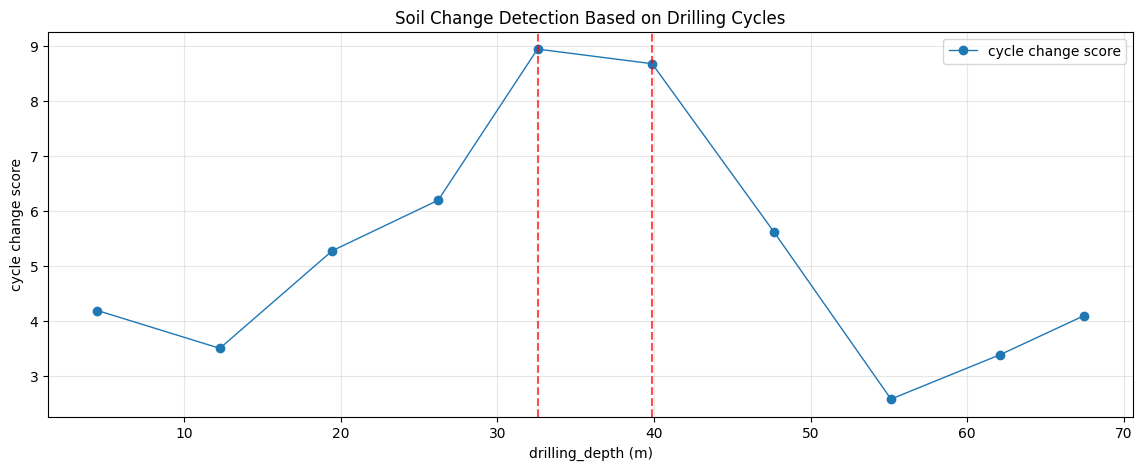

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    cycle_feature_df["mid_depth"],
    cycle_feature_df["cycle_change_score_smooth"],
    marker="o",
    linewidth=1,
    label="cycle change score"
)

for depth in boundaries:
    plt.axvline(
        depth,
        color="red",
        linestyle="--",
        alpha=0.7
    )

plt.xlabel("drilling_depth (m)")
plt.ylabel("cycle change score")
plt.title("Soil Change Detection Based on Drilling Cycles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


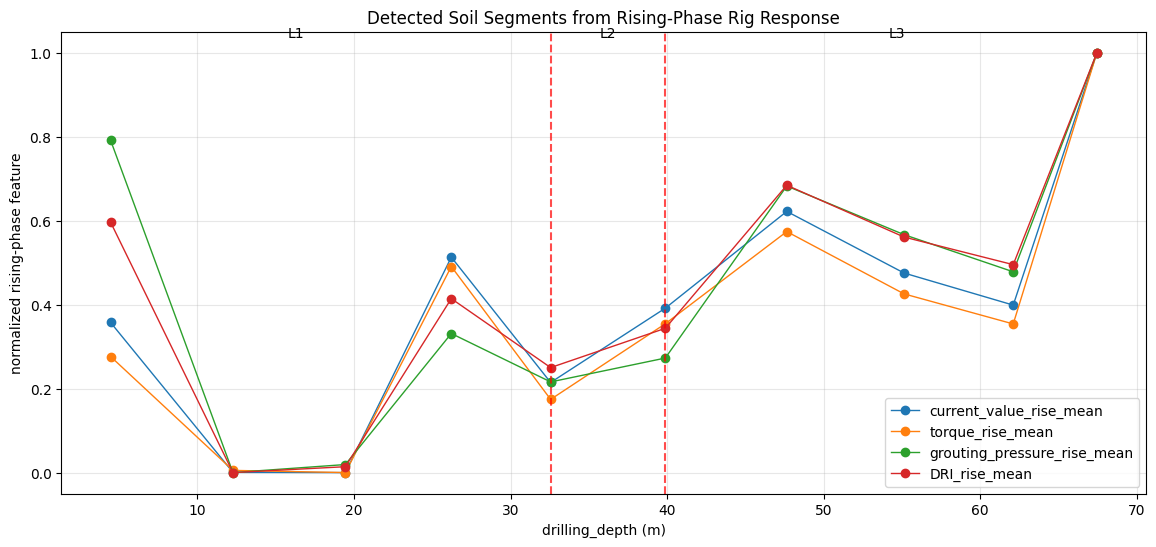

In [12]:
plot_cols = [
    "current_value_rise_mean",
    "torque_rise_mean",
    "grouting_pressure_rise_mean",
    "DRI_rise_mean",
]

plt.figure(figsize=(14, 6))

for col in plot_cols:
    y = cycle_feature_df[col]
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-9)

    plt.plot(
        cycle_feature_df["mid_depth"],
        y_norm,
        marker="o",
        linewidth=1,
        label=col
    )

for depth in boundaries:
    plt.axvline(
        depth,
        color="red",
        linestyle="--",
        alpha=0.7
    )

for _, row in detected_segments_df.iterrows():
    mid = (row["start_depth"] + row["end_depth"]) / 2

    plt.text(
        mid,
        1.03,
        f"L{int(row['detected_layer_index'])}",
        ha="center",
        va="bottom"
    )

plt.xlabel("drilling_depth (m)")
plt.ylabel("normalized rising-phase feature")
plt.title("Detected Soil Segments from Rising-Phase Rig Response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [13]:
report_boundaries = (
    soil_df["bottom_depth_representative_m"]
    .dropna()
    .astype(float)
    .sort_values()
    .tolist()
)

comparison_rows = []

for detected in boundaries:
    nearest = min(report_boundaries, key=lambda x: abs(x - detected))

    comparison_rows.append({
        "detected_boundary_depth": detected,
        "nearest_report_boundary_depth": nearest,
        "offset_m": detected - nearest,
        "abs_offset_m": abs(detected - nearest),
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df


,detected_boundary_depth,nearest_report_boundary_depth,offset_m,abs_offset_m
0,32.5585,31.00,1.5585,1.5585
1,39.8835,38.75,1.1335,1.1335


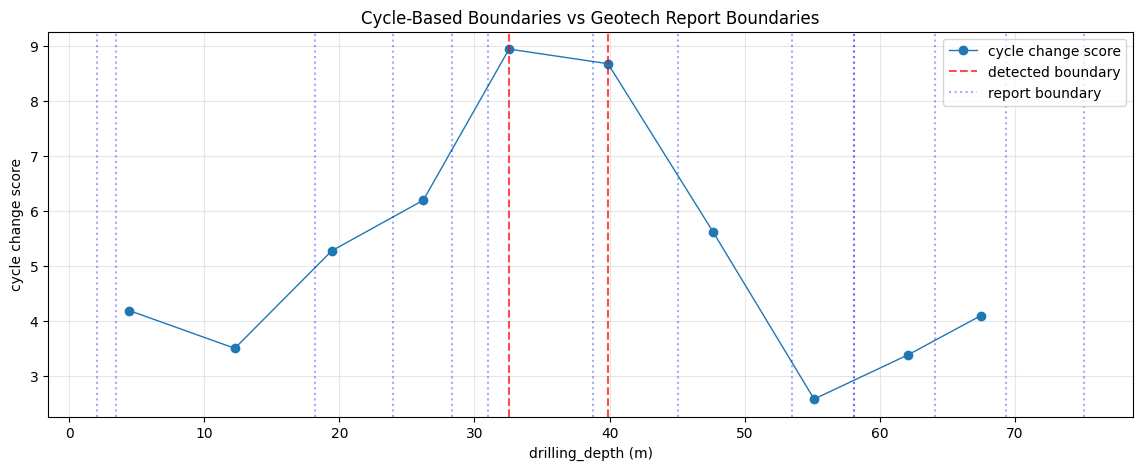

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(
    cycle_feature_df["mid_depth"],
    cycle_feature_df["cycle_change_score_smooth"],
    marker="o",
    linewidth=1,
    label="cycle change score"
)

for i, depth in enumerate(boundaries):
    plt.axvline(
        depth,
        color="red",
        linestyle="--",
        alpha=0.7,
        label="detected boundary" if i == 0 else None
    )

for i, depth in enumerate(report_boundaries):
    plt.axvline(
        depth,
        color="blue",
        linestyle=":",
        alpha=0.35,
        label="report boundary" if i == 0 else None
    )

plt.xlabel("drilling_depth (m)")
plt.ylabel("cycle change score")
plt.title("Cycle-Based Boundaries vs Geotech Report Boundaries")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [15]:
cycle_boundaries_df


,cycle_id,boundary_depth,cycle_change_score_smooth,start_depth,end_depth
0,2537,32.5585,8.945040,29.165,35.952
1,3027,39.8835,8.678542,35.954,43.813


In [16]:
detected_segments_df


,detected_layer_index,start_depth,end_depth,thickness,cycle_count,mean_change_score,current_rise_mean,torque_rise_mean,pressure_rise_mean,DRI_rise_mean
0,1,0.0000,32.5585,32.5585,5,5.618658,107.946250,29.320250,0.512700,-0.317535
1,2,32.5585,39.8835,7.3250,1,8.678542,128.823750,38.953750,0.513625,-0.088107
2,3,39.8835,69.5000,29.6165,4,3.916582,156.665781,52.615313,0.820719,0.796042


In [17]:
comparison_df


,detected_boundary_depth,nearest_report_boundary_depth,offset_m,abs_offset_m
0,32.5585,31.00,1.5585,1.5585
1,39.8835,38.75,1.1335,1.1335
